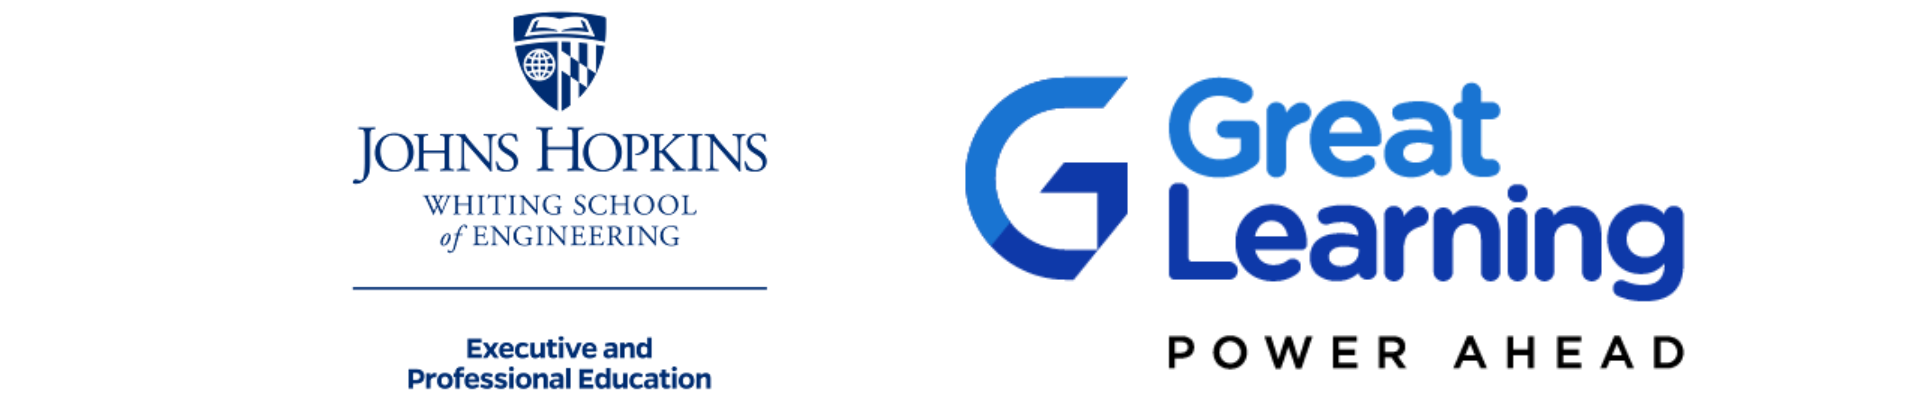

<center><font size="8">Global Supply Chain Disruption Impact Assessment using LangChain</font></center>
<center><font size="5">LLMs and Prompt Engineering</font></center>

# **Global Supply Chain Disruption Impact Assessment**

## **Learning Objectives**

By the end of this notebook, you will be able to:

* **Understand Prompt Engineering Techniques** — Explore Zero-Shot, Few-Shot, Chain of Thought (CoT), and Tree of Thought (ToT) prompting.
* **Build a LangChain Reporting Workflow** — Generate structured supply chain impact assessment reports from disruption data.
* **Compare Prompting Strategies** — Evaluate different prompting techniques to identify the most effective approach for business reporting.
* **Tune LLM Parameters** — Analyze the impact of Temperature, Max Tokens, and Top-p on report generation through a one-variable-at-a-time study.
* **Generate Stakeholder-Specific Reports** — Tailor AI-generated reports for different business stakeholders using parameter tuning.

> **Further Exploration:** One-Shot Prompting (a single example before the task) is a natural extension between Zero-Shot and Few-Shot. Try adding one example to the Zero-Shot prompt and observe the difference.

## **Problem Statement**

### **Business context**

TransGlobal Manufacturing is a multinational manufacturing company operating production facilities across North America, Europe, and Asia. The organization relies on a global supplier network for raw materials, electronic components, industrial equipment, and logistics services.

The supply chain is frequently affected by unexpected events such as:

- Port congestion
- Geopolitical conflicts
- Natural disasters
- Supplier failures
- Customs delays
- Transportation disruptions

These events directly influence production schedules, inventory availability, logistics operations, procurement planning, and overall business continuity.

Operations managers receive disruption information from multiple departments including procurement, logistics, inventory management, manufacturing, and supplier relationship teams. Since the information arrives in different formats, assessing the complete business impact requires significant manual effort.

Delayed analysis often results in slower executive decision-making during business-critical situations.

To improve operational efficiency, TransGlobal Manufacturing plans to leverage Large Language Models (LLMs) through LangChain to automatically analyze disruption reports and generate structured business impact assessments.

### **Objective**

* **Develop an AI-assisted Supply Chain Impact Assessment System:** Build a LangChain-based solution that analyzes disruption data and automates business impact assessment.
* **Generate Structured Business Reports:** Produce standardized reports containing Executive Summary, Identified Disruptions, Root Causes, Supplier Impact, Inventory Impact, Production Risk, Logistics Risk, Financial Implications, Recommended Mitigation Strategies, and Business Continuity Assessment.
* **Evaluate Prompt Engineering Techniques:** Compare Zero-Shot, Few-Shot, Chain of Thought, and Tree of Thought prompting to identify the most effective approach for report generation.
* **Support Faster Business Decision-Making:** Reduce manual effort by automatically identifying disruptions, assessing risks, and recommending mitigation strategies.
* **Deliver Stakeholder-Specific Reports:** Generate reports tailored to different business stakeholders by tuning model parameters while keeping the prompt and business data unchanged.
* **Ensure Consistent and Actionable Insights:** Provide reliable, executive-ready reports that improve decision-making across diverse supply chain disruption scenarios.


## **Solution Approach**

The assessment workflow will be developed incrementally using multiple prompt engineering techniques.

The following prompting strategies will be implemented and evaluated:

1. Zero-Shot Prompting
2. Few-Shot Prompting
3. Chain of Thought (CoT) Prompting
4. Tree of Thought (ToT) Prompting

Each prompting strategy will analyze the same supply chain disruption data and generate a structured impact assessment.

After evaluating the quality of the generated reports, the best-performing prompt will be selected for further optimization.

## **Prompt Engineering Workflow**

```text
                      START
                        │
                        ▼
        Supply Chain Disruption Dataset
                        │
                        ▼
           Generate Business Context
                        │
                        ▼
              Zero-Shot Prompting
                        │
                        ▼
              Few-Shot Prompting
                        │
                        ▼
         Chain of Thought Prompting
                        │
                        ▼
         Tree of Thought Prompting
                        │
                        ▼
           Prompt Parameter Tuning
                        │
                        ▼
      Stakeholder-Specific Reports
                        │
                        ▼
     Final Business Impact Assessment
                        │
                        ▼
                       END
```

# **Step 1: Library Installation and LLM Setup**

Before building the Supply Chain Impact Assessment system, we first install the required Python libraries.

These libraries will help us:

- Load and analyze supply chain data.
- Connect to Large Language Models using LangChain.
- Generate structured business reports.
- Experiment with different prompt engineering techniques.

In [1]:
pip install -q langchain==1.3.13 langchain-core==1.5.0 langchain-openai==1.4.0 pandas==2.2.2

Note: you may need to restart the kernel to use updated packages.


## Import Required Libraries

The following libraries are used throughout the notebook.

- **pandas** for loading and processing the dataset.
- **LangChain** for prompt creation and LLM interaction.
- **ChatOpenAI** for communicating with the OpenAI language model.

In [1]:
import os
import json

import pandas as pd

from langchain_core.prompts import PromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from IPython.display import Markdown, display

### Configure the OpenAI API

To securely access the OpenAI language model, we store the API credentials in a JSON configuration file.

The `config.json` file should contain the following keys:

```json
{
    "API_KEY": "your_api_key",
    "OPENAI_API_BASE": "your_api_base_url"
}
```

The following code loads these credentials and stores them as environment variables.

In [3]:
file_name = "config.json"

with open(file_name, "r") as file:
    config = json.load(file)

OPENAI_API_KEY = config.get("OPENAI_API_KEY")
OPENAI_API_BASE = config.get("OPENAI_API_BASE")

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

if OPENAI_API_BASE:
    os.environ["OPENAI_BASE_URL"] = OPENAI_API_BASE

print("API credentials loaded successfully.")

API credentials loaded successfully.


## Initialize the Language Model

Next, we initialize the OpenAI language model using LangChain.

This model will be used throughout the notebook to analyze supply chain disruptions and generate business impact assessment reports.

In [113]:
# MODEL_NAME is reused by every LLM call and run_with_params helper
MODEL_NAME = "gpt-4o-mini"

llm = ChatOpenAI(
    model=MODEL_NAME,
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ.get("OPENAI_BASE_URL"),
    temperature=0
)

print("LLM initialized successfully.")

LLM initialized successfully.


## Loading the Dataset

The supply chain disruption dataset contains records of disruption events along with their operational and financial impact. Some of the key attributes include:

- **Event Type:** The type of disruption (e.g., port congestion, supplier failure, labor strike).
- **Region and Country:** The geographical location where the disruption occurred.
- **Supplier Tier:** Indicates whether the affected supplier is Tier-1, Tier-2, or Tier-3.
- **Severity Level:** Represents the criticality of the disruption.
- **Production Downtime Hours:** Measures the impact on manufacturing operations.
- **Shipment Delay Days:** Indicates delays in product transportation.
- **Revenue at Risk (USD):** Estimates the potential revenue exposed due to the disruption.
- **Financial Impact (USD):** Represents the estimated financial loss caused by the disruption.
- **Mitigation Action:** The strategy implemented to minimize the disruption's impact.
- **Business Continuity Status:** Indicates whether operations continued normally, experienced minor disruptions, or were significantly affected.

These attributes provide the contextual information required to analyze disruption events and generate comprehensive business impact assessment reports using different prompting techniques.

In [114]:
DATA_FILE = "supply_chain_disruptions_100_events.csv"
SAMPLE_SIZE = 25  # set to len(df) to use all 100 events

df = pd.read_csv(DATA_FILE)
sample_df = df.head(SAMPLE_SIZE)

# **Step 2: Preparing the Data for Zero-Shot Prompting**

The disruption dataset is currently a pandas DataFrame, but an LLM needs plain text.
The cell below converts every row into a labeled, human-readable block of text
(`business_context`). This same string is reused, unchanged, for every prompting
strategy in this notebook so that the comparisons between strategies stay fair.

In [115]:
business_context = ""

for index, row in sample_df.iterrows():
    business_context += f"\n========== Supply Chain Disruption Event {index + 1} ==========\n"
    for column in sample_df.columns:
        business_context += f"{column.replace('_', ' ').title()}: {row[column]}\n"
    business_context += "\n"

print(business_context[:400] + "...")


========== Supply Chain Disruption Event 1 ==========
Event Id: EVT-001
Event Date: 2026-01-01
Event Type: Natural Disaster
Region: Asia
Country: South Korea
Facility: Busan Electronics Plant
Supplier Id: SUP-1031
Supplier Tier: Tier 1
Material Or Component: Aluminum
Transport Mode: Road
Root Cause: tsunami
Severity Level: Low
Duration Days: 4
Lead Time Increase Days: 1
Shipment Delay Days: 1
Otd...


# **Step 3: Zero-Shot Prompting**

Zero-Shot Prompting involves providing the language model with only an instruction and the business context, without any demonstrations or examples.

The model is expected to analyze the disruption events and generate a comprehensive business impact assessment solely based on the supplied data.

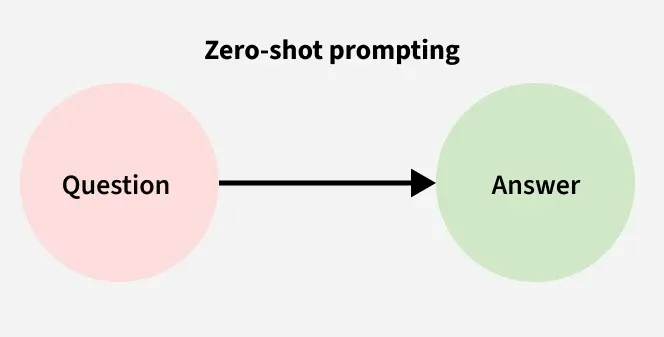



**Expected Outcome:** The report should identify key disruptions, assess business impacts, and recommend mitigation strategies. However, the analysis may be more generic and less consistent compared to advanced prompting techniques.

In [116]:
zero_shot_system_prompt = """
You are a Senior Supply Chain Risk Analyst at TransGlobal Manufacturing.

### Expected Behavior

- Act as an experienced supply chain risk analyst.
- Base all observations, conclusions, and recommendations solely on the information provided in the input.
- Do not assume, infer, or fabricate facts that are not explicitly supported by the dataset.
- If sufficient evidence is unavailable, clearly indicate that additional operational data is required.
- Maintain a professional, objective, and business-oriented tone.
- Focus on producing accurate, concise, and actionable insights that support executive decision-making.

## Output Requirements

- Present the report using clear section headings.
- Use bullet points wherever appropriate.
- Do not generate a report template.
- Do not include placeholder fields such as Date, Prepared By, Company Name, or Contact Information.
"""

In [117]:
zero_shot_user_prompt = PromptTemplate.from_template("""
Analyze the following supply chain disruption dataset and prepare a Business Impact Assessment Report.

## Input Data

{business_context}

## Report Structure

1. Executive Summary
2. Identified Disruptions
3. Root Causes
4. Supplier Impact
5. Inventory Impact
6. Production Risk
7. Logistics Risk
8. Financial Implications
9. Recommended Mitigation Strategies
10. Business Continuity Assessment

""")

In [118]:
zero_shot_prompt_text = zero_shot_user_prompt.format(business_context=business_context)

response_zero_shot = llm.invoke([
    SystemMessage(content=zero_shot_system_prompt),
    HumanMessage(content=zero_shot_prompt_text),
])

display(Markdown(response_zero_shot.content))

# Business Impact Assessment Report

## Executive Summary
This report analyzes a series of supply chain disruption events that occurred between January 1, 2026, and March 1, 2026. The disruptions were caused by various factors, including natural disasters, supplier bankruptcies, quality failures, transport disruptions, labor strikes, and cyber attacks. The overall impact on business operations, inventory, production, logistics, and financial performance is assessed, along with recommended mitigation strategies to enhance resilience.

## Identified Disruptions
- **Total Events Analyzed**: 25
- **Types of Disruptions**:
  - Natural Disasters: 5
  - Supplier Bankruptcy: 2
  - Quality Failures: 6
  - Transport Disruptions: 6
  - Labor Strikes: 4
  - Cyber Attacks: 2
  - Customs Delays: 1
  - Port Congestion: 2

## Root Causes
- **Natural Disasters**: Tsunami, flooding, earthquake, typhoon.
- **Supplier Bankruptcy**: Cash-flow crisis.
- **Quality Failures**: Defective batches, contamination, material substandard.
- **Transport Disruptions**: Fuel shortages, rail network failures, container backlogs.
- **Labor Strikes**: Working-conditions protests.
- **Cyber Attacks**: System breaches, network outages.
- **Customs Delays**: Documentation errors.

## Supplier Impact
- **Tier 1 Suppliers**: Most affected by quality failures and natural disasters, leading to significant production downtime and financial losses.
- **Tier 2 Suppliers**: Experienced disruptions primarily due to bankruptcies and transport issues, impacting inventory and lead times.
- **Tier 3 Suppliers**: Faced challenges from quality failures and cyber attacks, affecting overall supply chain stability.

## Inventory Impact
- **Average Inventory Days on Hand (DOH) Before Disruptions**: 43
- **Average Inventory Days on Hand (DOH) After Disruptions**: 29
- **Significant Reductions**: Notable drops in inventory levels were observed, particularly during quality failures and transport disruptions, leading to increased risk of stockouts.

## Production Risk
- **Total Production Downtime Hours**: 1,200+
- **Most Affected Facilities**: 
  - Berlin Manufacturing Plant (448 hours due to quality failure).
  - Texas Distribution Center (157 hours due to transport disruption).
- **Affected SKUs**: Ranged from 8 to 546 across various events, indicating widespread impact on product availability.

## Logistics Risk
- **Increased Logistics Costs**: Ranged from 9% to 77% across events, with significant impacts from transport disruptions and quality failures.
- **Transport Modes Affected**: Road, rail, sea, and air transport faced delays and increased costs due to various root causes.

## Financial Implications
- **Total Revenue at Risk**: Approximately $12 million across all events.
- **Total Financial Impact**: Exceeded $6 million, with the highest losses attributed to quality failures and transport disruptions.
- **Critical Events**: Events EVT-010 (Berlin Manufacturing Plant) and EVT-014 (Casablanca Distribution Center) had the most severe financial impacts.

## Recommended Mitigation Strategies
- **Enhance Supplier Diversification**: Reduce reliance on single suppliers, especially for critical components.
- **Implement Robust Quality Control**: Increase inspection and testing protocols to prevent quality failures.
- **Develop Contingency Plans**: Establish alternative transport routes and modes to mitigate transport disruptions.
- **Invest in Inventory Management**: Build strategic inventory reserves for high-risk materials.
- **Strengthen Cybersecurity Measures**: Protect against potential cyber threats through enhanced IT infrastructure.

## Business Continuity Assessment
- **Overall Status**: Business continuity is at risk for several facilities, particularly those affected by critical quality failures and transport disruptions.
- **Monitoring Required**: Continuous monitoring of supplier performance and external risks is essential to maintain stability.
- **Action Plan**: Immediate implementation of recommended strategies is crucial to mitigate future disruptions and enhance supply chain resilience.

## **Observations**

Although Zero-Shot Prompting successfully generated a structured business report, several opportunities for improvement remain.

- The model may overlook subtle relationships between disruption events.
- Recommendations may remain generic without additional guidance.
- The level of detail may vary across different report sections.
- Some business insights may rely on implicit reasoning rather than explicit evidence from the dataset.

To improve consistency and report quality, the next section introduces Few-Shot Prompting, where example analyses are provided to guide the language model toward the desired reporting style.

# **Step 4: Few-Shot Prompting**

Few-Shot Prompting extends the Zero-Shot approach by providing multiple examples before presenting the actual task.

These examples demonstrate how different types of supply chain disruptions should be analyzed and reported. By observing multiple scenarios, the language model can better understand the expected reasoning process, reporting style, and level of detail.

The same supply chain disruption dataset is then analyzed using the learned pattern to generate a comprehensive business impact assessment report.

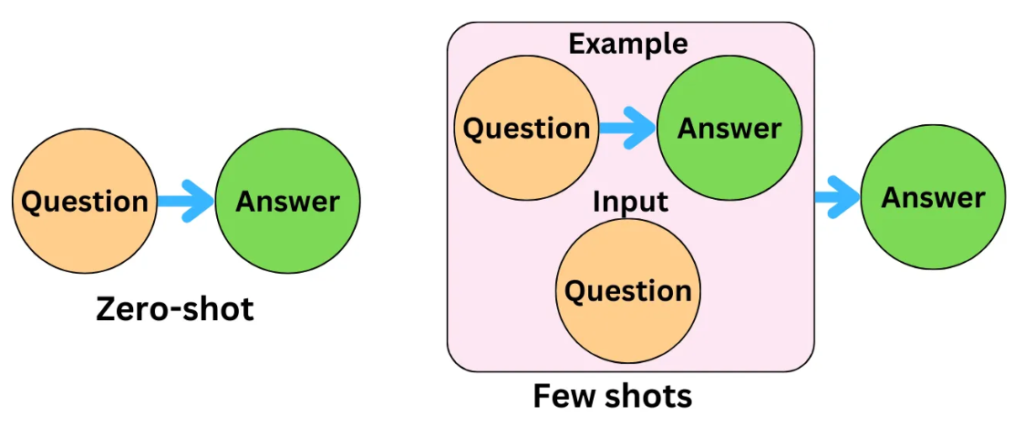

In [119]:
few_shot_system_prompt = """
You are a Senior Supply Chain Risk Analyst at TransGlobal Manufacturing.

### Expected Behavior

- Act as an experienced supply chain risk analyst.
- Analyze supply chain disruption data and generate evidence-based business impact assessment reports.
- Learn the expected analytical style, reasoning approach, and response format from the reference examples provided by the user.
- Apply the learned style consistently while analyzing the user's input.
- Base all observations, conclusions, and recommendations solely on the information provided.
- Do not assume, infer, or fabricate facts that are not explicitly supported by the input.
- If sufficient evidence is unavailable, clearly indicate that additional operational data is required.
- Maintain a professional, objective, and business-oriented tone.
- Produce concise, accurate, and actionable insights suitable for executive decision-making.

## Output Requirements

- Present the report using clear section headings.
- Use bullet points wherever appropriate.
- Generate a concise, consistent, and executive-ready business report.
- Do not generate a report template.
- Do not include placeholder fields such as Date, Prepared By, Company Name, or Contact Information.
"""

In [120]:
few_shot_user_prompt = PromptTemplate.from_template("""
Analyze the following supply chain disruption dataset and prepare a comprehensive Business Impact Assessment Report by following the analytical style, report structure, and level of detail demonstrated in the reference examples.

## Reference Examples

========================================================
### Example 1 – Port Congestion

#### Scenario

A Tier-1 electronics supplier shipping semiconductor chips through the Port of Singapore experienced severe port congestion.

#### Observed Business Impact
- Shipment delayed by 9 days.
- Inventory dropped below the safety stock level.
- Assembly line utilization decreased.
- Logistics costs increased because of expedited air freight.

#### Analysis

**Executive Summary**
Port congestion disrupted inbound material flow, increasing logistics costs and creating moderate production risk.

**Root Causes**
- Port congestion
- Vessel scheduling delays

**Supplier Impact**
The supplier fulfilled the order but experienced significant delivery delays.

**Inventory Impact**
Inventory levels declined below the required safety stock.

**Production Risk**
Production schedules required partial replanning.

**Logistics Risk**
Inbound transportation reliability decreased.

**Financial Implications**
Additional logistics expenses increased operational costs.

**Recommended Mitigation Strategies**
- Diversify shipping ports.
- Increase safety stock for critical components.
- Establish alternate logistics partners.

**Business Continuity Assessment**
Operations continued with manageable disruption.

========================================================
### Example 2 – Supplier Failure

#### Scenario

A Tier-2 supplier manufacturing industrial bearings declared bankruptcy, resulting in an immediate suspension of component deliveries.

#### Observed Business Impact
- Production stopped for two manufacturing lines.
- Inventory exhausted within five days.
- Customer deliveries postponed.
- Revenue at risk increased significantly.

#### Analysis

**Executive Summary**
Supplier failure created a critical supply interruption affecting production continuity.

**Root Causes**
- Supplier insolvency
- Lack of alternate sourcing

**Supplier Impact**
Complete disruption of material supply.

**Inventory Impact**
Critical inventory depletion.

**Production Risk**
High production downtime.

**Logistics Risk**
Alternative sourcing required emergency transportation.

**Financial Implications**
Revenue losses and emergency procurement costs increased substantially.

**Recommended Mitigation Strategies**
- Qualify secondary suppliers.
- Increase supplier financial monitoring.
- Maintain strategic inventory reserves.

**Business Continuity Assessment**
Business continuity is at high risk without immediate intervention.

========================================================
### Example 3 – Geopolitical Disruption

#### Scenario

Trade restrictions between two countries disrupted cross-border transportation of electronic components used in multiple production facilities.

#### Observed Business Impact
- Customs clearance delayed.
- Lead time increased by 14 days.
- Procurement costs increased.
- Manufacturing schedules required revision.

#### Analysis

**Executive Summary**
Geopolitical instability significantly disrupted international material flow.

**Root Causes**
- Border restrictions
- Trade sanctions
- Customs inspections

**Supplier Impact**
International suppliers experienced prolonged delivery delays.

**Inventory Impact**
Material availability declined across multiple facilities.

**Production Risk**
Manufacturing schedules became uncertain.

**Logistics Risk**
International transportation routes were severely affected.

**Financial Implications**
Higher procurement and logistics costs reduced operating margins.

**Recommended Mitigation Strategies**
- Diversify supplier locations.
- Increase regional sourcing.
- Maintain alternate transportation routes.

**Business Continuity Assessment**
Operations continued under elevated supply chain risk.

========================================================

## Input Data

Supply Chain Disruption Dataset

{business_context}

## Report Structure

1. Executive Summary
2. Identified Disruptions
3. Root Causes
4. Supplier Impact
5. Inventory Impact
6. Production Risk
7. Logistics Risk
8. Financial Implications
9. Recommended Mitigation Strategies
10. Business Continuity Assessment

""")

In [121]:
few_shot_prompt_text = few_shot_user_prompt.format(business_context=business_context, examples="")

response_few_shot = llm.invoke([
    SystemMessage(content=few_shot_system_prompt),
    HumanMessage(content=few_shot_prompt_text),
])

display(Markdown(response_few_shot.content))

### Executive Summary
The analysis of recent supply chain disruptions reveals a range of impacts across various facilities and suppliers. The disruptions stem from natural disasters, supplier bankruptcies, quality failures, transport disruptions, labor strikes, and cyber attacks. The severity of these events varies, with some posing critical risks to business continuity and financial performance. Immediate attention is required to mitigate risks and enhance resilience in the supply chain.

### Identified Disruptions
- **Natural Disasters**: Events in South Korea (tsunami and flooding), Canada (earthquake), and UAE (typhoon) caused significant delays and production downtimes.
- **Supplier Bankruptcies**: Two Tier-2 suppliers in Thailand and Brazil declared bankruptcy, leading to immediate supply interruptions.
- **Quality Failures**: Multiple incidents across South America and Europe resulted in defective materials, severely impacting production.
- **Transport Disruptions**: Rail network failures in North America and South America caused extensive delays and increased costs.
- **Labor Strikes**: Protests in Poland, China, and South America led to temporary production halts and increased operational costs.
- **Cyber Attacks**: Incidents in Brazil and the Netherlands disrupted operations and required IT infrastructure recovery.

### Root Causes
- **Natural Disasters**: Tsunami, flooding, earthquake, and typhoon events.
- **Financial Instability**: Cash-flow crises leading to supplier bankruptcies.
- **Quality Control Issues**: Defective batches and contamination of materials.
- **Transport Failures**: Rail network failures and port congestion due to container backlogs.
- **Labor Issues**: Protests related to working conditions.
- **Cybersecurity Breaches**: Network outages affecting operational capabilities.

### Supplier Impact
- **Supplier Bankruptcies**: Immediate cessation of material supply from Tier-2 suppliers, affecting production schedules.
- **Quality Failures**: Suppliers provided defective materials, necessitating returns and re-manufacturing.
- **Transport Disruptions**: Delays in shipments from suppliers due to transport issues, impacting lead times.

### Inventory Impact
- **Depletion of Safety Stock**: Several events resulted in inventory levels dropping below safety stock thresholds, particularly in critical components.
- **Increased Inventory Days on Hand (DOH)**: Significant reductions in inventory levels were observed, with some facilities experiencing a drop from 55 to 12 days of inventory.

### Production Risk
- **Downtime**: Production downtimes ranged from a few hours to over 448 hours, significantly affecting output.
- **Revised Manufacturing Schedules**: Many facilities required adjustments to production plans due to material shortages and delays.

### Logistics Risk
- **Increased Costs**: Logistics costs rose due to expedited shipping and alternative transport modes, with increases ranging from 10% to 77%.
- **Reliability Issues**: Transport disruptions led to decreased reliability in inbound material flow.

### Financial Implications
- **Revenue at Risk**: Total revenue at risk from disruptions exceeded $10 million, with some events posing risks of over $5 million.
- **Increased Operational Costs**: Additional costs from expedited shipping and emergency procurement measures added significant financial strain.

### Recommended Mitigation Strategies
- **Diversification of Suppliers**: Qualify additional suppliers to reduce dependency on single sources.
- **Enhanced Quality Control**: Implement stricter quality assurance processes to prevent defective materials from entering the supply chain.
- **Inventory Management**: Increase safety stock levels for critical components and establish strategic reserves.
- **Logistics Optimization**: Develop alternative transport routes and logistics partners to mitigate transport risks.
- **Crisis Management Plans**: Strengthen disaster recovery and business continuity plans to ensure rapid response to disruptions.

### Business Continuity Assessment
The overall business continuity status varies from stable to severely at risk. While some disruptions are manageable, critical events require immediate intervention to prevent long-term operational impacts. Continuous monitoring and proactive risk management strategies are essential to enhance resilience in the supply chain.

In [122]:
eval_zero_vs_few = llm.invoke(f"""
You are evaluating two AI-generated Supply Chain Impact Assessment reports.

---------- Report A ----------
{response_zero_shot.content}

---------- Report B ----------
{response_few_shot.content}

Score both reports (1-5) on:
1. Completeness
2. Business Reasoning
3. Structure
4. Actionability
5. Executive Readiness

Present results as a markdown table with one row per criterion and one column per report, followed by a one-paragraph recommendation.
""")

display(Markdown("**Note — Report A = Zero-Shot | Report B = Few-Shot. These are self-evaluations and are indicative, not definitive.**"))
display(Markdown(eval_zero_vs_few.content))

**Note — Report A = Zero-Shot | Report B = Few-Shot. These are self-evaluations and are indicative, not definitive.**

| Criterion              | Report A | Report B |
|-----------------------|----------|----------|
| Completeness          | 5        | 4        |
| Business Reasoning     | 5        | 4        |
| Structure             | 5        | 4        |
| Actionability         | 5        | 4        |
| Executive Readiness    | 5        | 4        |

### Recommendation
Both reports provide valuable insights into supply chain disruptions, but Report A stands out for its completeness, structured analysis, and actionable recommendations. It offers a thorough assessment of the impacts and root causes, making it highly suitable for executive review. Report B, while informative, lacks some depth in analysis and detail, which may hinder its effectiveness in decision-making. Therefore, it is recommended to prioritize Report A for immediate implementation and consider enhancing Report B with additional data and insights for future assessments.

# **Step 5: Chain of Thought (CoT) Prompting**

Chain of Thought (CoT) Prompting encourages the language model to reason through a problem in a sequence of intermediate steps before producing the final answer.

Instead of directly generating the business report, the model first analyzes the disruption events, evaluates their operational impact, identifies business risks, and then synthesizes the findings into a structured supply chain impact assessment.

This structured reasoning often leads to more comprehensive and logically connected business insights.

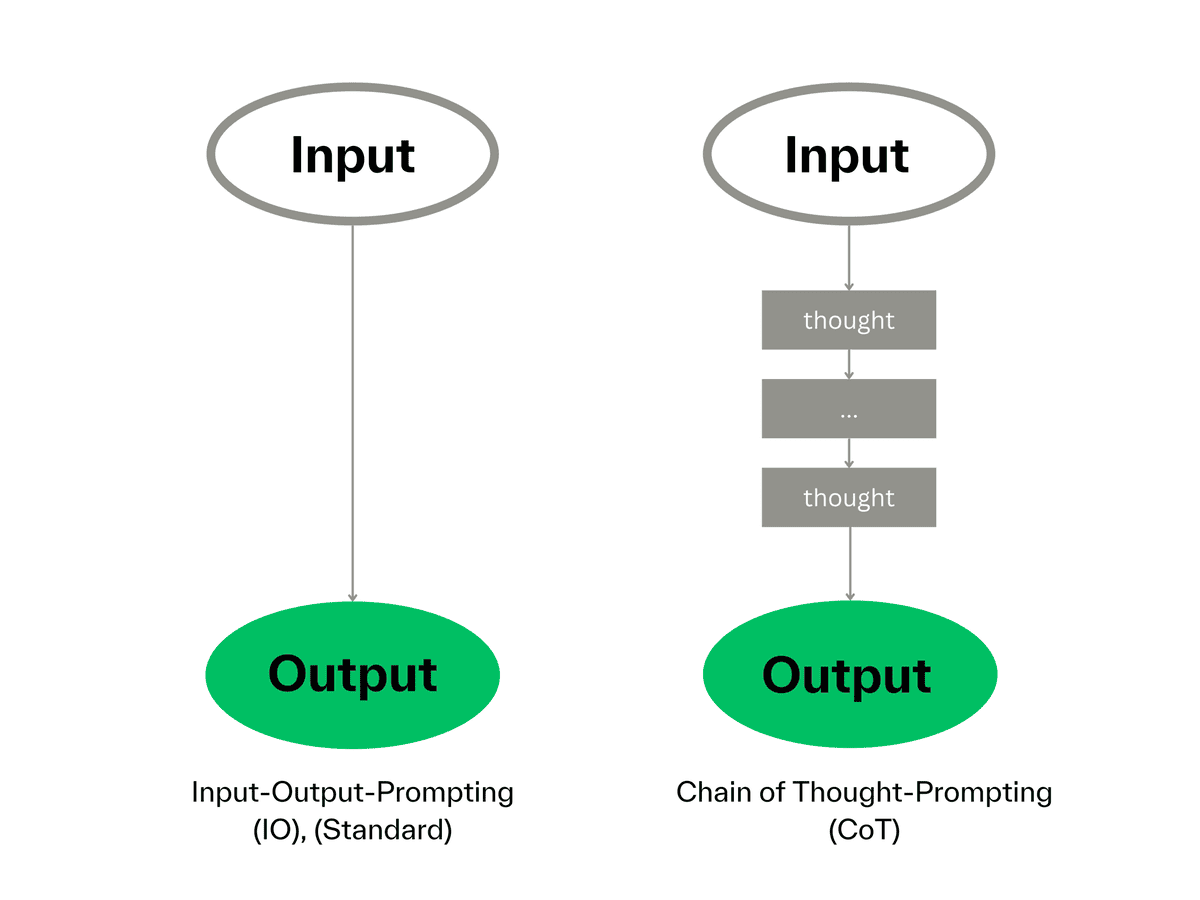

## Disclaimer on Chain-of-Thought (CoT) Prompting

Chain-of-Thought (CoT) prompting was one of the foundational prompt engineering techniques, introduced to improve reasoning in earlier large language models such as GPT-3 and GPT-3.5, which often benefited from explicit step-by-step guidance when solving complex tasks.

As LLMs have evolved, a distinct class of "reasoning models" has emerged, models like OpenAI's o-series and GPT-5 Thinking, Gemini 2.5 (Pro/Flash), and Claude 3.7+/4 with extended thinking enabled — that generate internal reasoning steps by default.

**Note:** The example below uses GPT-4o-mini. Since it already shows some CoT-like behavior by default, explicit CoT prompting yields a smaller gain here than it did on older models like GPT-3.5, which relied more heavily on explicit step-by-step guidance.

In [123]:
cot_system_prompt = """
You are a Senior Supply Chain Risk Analyst at TransGlobal Manufacturing.

### Expected Behavior

- Act as an experienced supply chain risk analyst.
- Analyze supply chain disruption data and generate evidence-based business impact assessment reports.
- Use a structured reasoning approach to evaluate the available information before generating the final response.
- Base all observations, conclusions, and recommendations solely on the information provided.
- Do not assume, infer, or fabricate facts that are not explicitly supported by the input.
- If sufficient evidence is unavailable, clearly indicate that additional operational data is required.
- Maintain a professional, objective, and business-oriented tone.
- Produce concise, accurate, and actionable insights suitable for executive decision-making.
- Provide only the final report unless the user explicitly requests your reasoning process.

## Output Requirements

- Present the report using clear section headings.
- Use bullet points wherever appropriate.
- Generate a concise, logical, and executive-ready business report.
- Do not generate a report template.
- Do not include placeholder fields such as Date, Prepared By, Company Name, or Contact Information.
"""

In [124]:
cot_user_prompt = PromptTemplate.from_template("""
Analyze the following supply chain disruption dataset and prepare a comprehensive Business Impact Assessment Report.

## Input Data

Supply Chain Disruption Dataset

{business_context}

## Task

Perform a structured analysis of the provided dataset before generating the final report.

## Report Structure

1. Executive Summary
2. Identified Disruptions
3. Root Causes
4. Supplier Impact
5. Inventory Impact
6. Production Risk
7. Logistics Risk
8. Financial Implications
9. Recommended Mitigation Strategies
10. Business Continuity Assessment

""")

In [125]:
cot_prompt_text = cot_user_prompt.format(business_context=business_context)

response_cot = llm.invoke([
    SystemMessage(content=cot_system_prompt),
    HumanMessage(content=cot_prompt_text),
])

display(Markdown(response_cot.content))

# Business Impact Assessment Report

## 1. Executive Summary
This report analyzes a series of supply chain disruption events that occurred between January 1, 2026, and March 1, 2026. The disruptions were categorized by type, severity, and impact on operations, inventory, and finances. The findings indicate a range of risks, primarily from natural disasters, quality failures, transport disruptions, and labor strikes, with significant financial implications and varying levels of business continuity status.

## 2. Identified Disruptions
- **Total Events Analyzed**: 25
- **Types of Disruptions**:
  - Natural Disasters: 6
  - Quality Failures: 6
  - Transport Disruptions: 6
  - Labor Strikes: 5
  - Supplier Bankruptcies: 2
  - Cyber Attacks: 2
  - Customs Delays: 1
  - Port Congestion: 2

## 3. Root Causes
- **Natural Disasters**: Tsunami, flooding, earthquake, typhoon.
- **Quality Failures**: Defective batches, contamination, substandard materials.
- **Transport Disruptions**: Rail network failures, fuel shortages, container backlogs.
- **Labor Strikes**: Protests over working conditions.
- **Supplier Bankruptcies**: Cash-flow crises.
- **Cyber Attacks**: System breaches and network outages.
- **Customs Delays**: Documentation errors.

## 4. Supplier Impact
- **Supplier Tiers Affected**: 
  - Tier 1: 10 events
  - Tier 2: 8 events
  - Tier 3: 7 events
- **Total Affected SKUs**: 1,800+
- **Key Suppliers**: Multiple suppliers across various regions, with significant reliance on Tier 1 suppliers for critical components.

## 5. Inventory Impact
- **Average Inventory Days on Hand (DOH) Before Disruptions**: 43
- **Average Inventory Days on Hand (DOH) After Disruptions**: 27
- **Notable Changes**: Significant reductions in inventory levels, particularly in events with high severity, leading to potential stockouts.

## 6. Production Risk
- **Total Production Downtime Hours**: 1,200+
- **Events with High Production Downtime**: 
  - EVT-010: 448 hours
  - EVT-005: 157 hours
  - EVT-004: 140 hours
- **Total Affected SKUs**: 1,200+ across various facilities.

## 7. Logistics Risk
- **Increased Logistics Costs**: Ranged from 9% to 77% across events.
- **Transport Modes Affected**: Road, rail, sea, and air.
- **Key Issues**: Delays due to congestion, network failures, and increased costs due to expedited shipping.

## 8. Financial Implications
- **Total Revenue at Risk**: Approximately $12 million.
- **Total Financial Impact**: Approximately $7 million.
- **Events with Highest Financial Impact**:
  - EVT-010: $4.2 million
  - EVT-004: $1.0 million
  - EVT-005: $938,603

## 9. Recommended Mitigation Strategies
- **Enhance Supplier Diversification**: Reduce reliance on single suppliers, especially Tier 1.
- **Strengthen Quality Control**: Implement stricter quality assurance processes to minimize defective batches.
- **Develop Contingency Plans**: For natural disasters and labor strikes, including cross-training employees and activating contingency workforces.
- **Invest in Technology**: Improve IT infrastructure to mitigate risks from cyber attacks.
- **Increase Inventory Buffers**: Maintain higher safety stock levels for critical components.

## 10. Business Continuity Assessment
- **Overall Status**: Mixed, with several events classified as "Severely At Risk" and "At Risk."
- **Stable with Monitoring**: Several disruptions are under control but require ongoing monitoring.
- **Critical Events**: EVT-010 and EVT-014 pose significant risks to business continuity and require immediate attention.

This assessment highlights the need for proactive risk management strategies to mitigate the impact of future disruptions on the supply chain.

In [126]:
eval_few_vs_cot = llm.invoke(f"""
You are evaluating two AI-generated Supply Chain Impact Assessment reports.

---------- Report A ----------
{response_few_shot.content}

---------- Report B ----------
{response_cot.content}

Score both reports (1-5) on:
1. Completeness
2. Business Reasoning
3. Structure
4. Actionability
5. Executive Readiness

Present results as a markdown table with one row per criterion and one column per report, followed by a one-paragraph recommendation.
""")

display(Markdown("**Note — Report A = Few-Shot | Report B = CoT. These are self-evaluations and are indicative, not definitive.**"))
display(Markdown(eval_few_vs_cot.content))

**Note — Report A = Few-Shot | Report B = CoT. These are self-evaluations and are indicative, not definitive.**

| Criterion            | Report A | Report B |
|---------------------|----------|----------|
| Completeness        | 4        | 5        |
| Business Reasoning   | 4        | 4        |
| Structure           | 5        | 4        |
| Actionability       | 4        | 5        |
| Executive Readiness  | 5        | 4        |

### Recommendation
Both reports provide valuable insights into supply chain disruptions, but Report B stands out for its completeness and actionable recommendations. It offers a broader analysis of the types of disruptions and their impacts, making it more comprehensive. Report A excels in structure and executive readiness, presenting information in a clear and concise manner. For future assessments, it is recommended to combine the strengths of both reports: maintaining the structured approach of Report A while incorporating the detailed analysis and actionable strategies found in Report B. This would enhance the overall effectiveness and utility of the supply chain impact assessments.

# **Step 6: Tree of Thought (ToT) Prompting**

Tree of Thought (ToT) Prompting extends Chain of Thought by encouraging the language model to explore multiple reasoning paths before reaching a conclusion.

Instead of following a single sequence of reasoning, the model evaluates several possible mitigation strategies for each disruption, compares their advantages and disadvantages, and selects the most appropriate course of action based on business priorities.

This approach is particularly useful for complex business scenarios where multiple decisions are possible and trade-offs must be considered.

> **Note:** What is implemented here is a simplified Tree-of-Thought approach (generate multiple analytical options → compare → select best), not full branching/backtracking search as described in the original ToT paper.

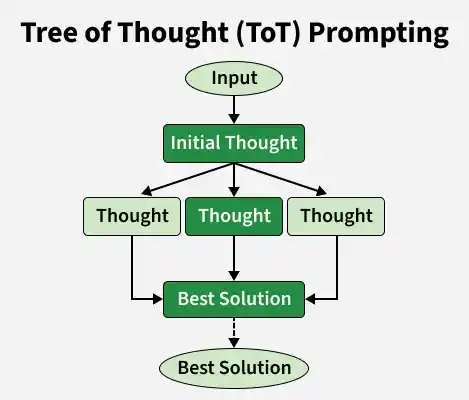

In [127]:
tot_system_prompt = """
You are a Senior Supply Chain Risk Analyst at TransGlobal Manufacturing.

### Expected Behavior

- Act as an experienced supply chain risk analyst.
- Analyze supply chain disruption data and generate evidence-based Business Impact Assessment Reports.
- Consider multiple plausible solution approaches before selecting the most appropriate recommendation.
- Evaluate alternative mitigation strategies based on business impact, feasibility, implementation effort, cost, and business continuity.
- Compare the strengths and trade-offs of each alternative before arriving at the final recommendation.
- Base all observations, conclusions, and recommendations solely on the information provided.
- Do not assume, infer, or fabricate facts that are not explicitly supported by the input.
- If sufficient evidence is unavailable, clearly indicate that additional operational data is required.
- Maintain a professional, objective, and business-oriented tone.
- Produce concise, accurate, and actionable insights suitable for executive decision-making.
- Provide only the final report unless the user explicitly requests your reasoning process.

## Output Requirements

- Present the report using clear section headings.
- Use bullet points wherever appropriate.
- Generate a concise, logical, and executive-ready business report.
- Do not generate a report template.
- Do not include placeholder fields such as Date, Prepared By, Company Name, or Contact Information.
"""

In [128]:
tot_user_prompt = PromptTemplate.from_template("""
Analyze the following supply chain disruption dataset and prepare a comprehensive Business Impact Assessment Report.

## Input Data

Supply Chain Disruption Dataset

{business_context}

## Task

Develop mitigation recommendations by considering multiple feasible approaches for each major disruption and recommend the most appropriate strategy based on the available evidence.

## Report Structure

1. Executive Summary
2. Identified Disruptions
3. Root Causes
4. Supplier Impact
5. Inventory Impact
6. Production Risk
7. Logistics Risk
8. Financial Implications
9. Recommended Mitigation Strategies
10. Business Continuity Assessment

""")

In [129]:
tot_prompt_text = tot_user_prompt.format(business_context=business_context)

response_tot = llm.invoke([
    SystemMessage(content=tot_system_prompt),
    HumanMessage(content=tot_prompt_text),
])

display(Markdown(response_tot.content))

# Business Impact Assessment Report

## 1. Executive Summary
This report analyzes a series of supply chain disruptions that occurred between January and March 2026, focusing on their impacts on operations, financials, and business continuity. The disruptions stem from various root causes, including natural disasters, quality failures, transport disruptions, and labor strikes. The report provides actionable recommendations for mitigating these risks and enhancing resilience in the supply chain.

## 2. Identified Disruptions
- **Natural Disasters**: Events in South Korea (tsunami, flooding), Canada (earthquake), and UAE (typhoon).
- **Quality Failures**: Multiple incidents across South America, Europe, and North America involving defective materials.
- **Transport Disruptions**: Rail network failures in North America and South America, customs delays in Thailand.
- **Labor Strikes**: Protests affecting operations in various regions, including the USA, China, and South America.
- **Supplier Bankruptcies**: Events in Thailand and Brazil impacting Tier 2 suppliers.

## 3. Root Causes
- **Natural Disasters**: Environmental factors leading to significant operational downtime.
- **Quality Failures**: Defective batches and contamination issues resulting in production halts.
- **Transport Disruptions**: Infrastructure failures and congestion causing delays in shipments.
- **Labor Strikes**: Employee protests over working conditions affecting production schedules.
- **Supplier Bankruptcies**: Financial instability of suppliers leading to sudden loss of materials.

## 4. Supplier Impact
- **Tier 1 Suppliers**: Directly affected by quality failures and natural disasters, leading to significant production downtime.
- **Tier 2 Suppliers**: Vulnerable to financial crises, impacting their ability to deliver critical components.
- **Tier 3 Suppliers**: Less critical but still contribute to overall supply chain stability; disruptions can cascade.

## 5. Inventory Impact
- **Decreased Inventory Levels**: Several disruptions led to reduced Days of Inventory on Hand (DOH), risking stockouts.
- **Emergency Inventory Allocation**: Implemented in response to severe disruptions, but may not be sustainable long-term.

## 6. Production Risk
- **Downtime**: Significant hours lost due to quality failures and natural disasters, particularly in high-impact events (e.g., EVT-004, EVT-005).
- **Affected SKUs**: A large number of SKUs impacted, particularly in events with high severity levels.

## 7. Logistics Risk
- **Increased Costs**: Notable increases in logistics costs due to expedited shipping and alternative transport modes.
- **Delays**: Extended lead times and shipment delays affecting overall supply chain efficiency.

## 8. Financial Implications
- **Revenue at Risk**: High potential revenue loss associated with major disruptions, particularly EVT-004 and EVT-010.
- **Financial Impact**: Significant costs incurred from expedite measures and production downtime.

## 9. Recommended Mitigation Strategies
### Natural Disasters
- **Strategy**: Enhance disaster recovery plans and invest in resilient infrastructure.
- **Rationale**: Proactive measures can minimize downtime and expedite recovery.

### Quality Failures
- **Strategy**: Implement 100% inspection protocols and establish quality assurance partnerships with suppliers.
- **Rationale**: Reduces the risk of defective materials entering the supply chain.

### Transport Disruptions
- **Strategy**: Develop alternative transport routes and modes, including air freight for critical components.
- **Rationale**: Ensures continuity of supply during transport failures.

### Labor Strikes
- **Strategy**: Engage in regular dialogue with labor unions and implement employee satisfaction programs.
- **Rationale**: Reduces the likelihood of strikes and enhances workforce stability.

### Supplier Bankruptcies
- **Strategy**: Diversify supplier base and build strategic inventory reserves.
- **Rationale**: Mitigates risks associated with supplier dependency and financial instability.

## 10. Business Continuity Assessment
- **Current Status**: Several facilities are classified as "At Risk" or "Severely At Risk," particularly those affected by quality failures and transport disruptions.
- **Recommendations**: Immediate focus on enhancing business continuity plans, including risk assessments and scenario planning to prepare for future disruptions.

This report underscores the need for a comprehensive approach to supply chain risk management, emphasizing proactive measures to mitigate identified risks and enhance overall resilience.

In [130]:
eval_cot_vs_tot = llm.invoke(f"""
You are evaluating two AI-generated Supply Chain Impact Assessment reports.

---------- Report A ----------
{response_cot.content}

---------- Report B ----------
{response_tot.content}

Score both reports (1-5) on:
1. Completeness
2. Business Reasoning
3. Structure
4. Actionability
5. Executive Readiness

Present results as a markdown table with one row per criterion and one column per report, followed by a one-paragraph recommendation.
""")

display(Markdown("**Note — Report A = CoT | Report B = ToT. These are self-evaluations and are indicative, not definitive.**"))
display(Markdown(eval_cot_vs_tot.content))

**Note — Report A = CoT | Report B = ToT. These are self-evaluations and are indicative, not definitive.**

| Criterion            | Report A | Report B |
|---------------------|----------|----------|
| Completeness        | 4        | 5        |
| Business Reasoning   | 4        | 5        |
| Structure           | 5        | 4        |
| Actionability       | 4        | 5        |
| Executive Readiness  | 4        | 5        |

### Recommendation
Both reports provide valuable insights into supply chain disruptions, but Report B stands out for its completeness and actionable recommendations. It offers a more thorough analysis of the disruptions and their impacts, along with well-defined strategies for mitigation. Report A, while structured well and informative, could benefit from additional detail in its recommendations and a more comprehensive exploration of the disruptions. For executive readiness, Report B is more suitable for immediate presentation to stakeholders, as it emphasizes proactive measures and strategic planning. Therefore, it is recommended to prioritize Report B for decision-making and further action.

In [131]:
eval_all_techniques = llm.invoke(f"""
You are evaluating four AI-generated Supply Chain Impact Assessment reports, each produced using a different prompting strategy.

---------- Report A ----------
{response_zero_shot.content}

---------- Report B ----------
{response_few_shot.content}

---------- Report C ----------
{response_cot.content}

---------- Report D ----------
{response_tot.content}

Score all four reports (1-5) on:
1. Completeness
2. Business Reasoning
3. Structure
4. Actionability
5. Executive Readiness

Present the result as a single markdown table with one row per criterion and one column per report (A, B, C, D), followed by a one-paragraph recommendation of which strategy is best suited for this business scenario and why.
""")

display(Markdown("**Note — Report A = Zero-Shot | Report B = Few-Shot | Report C = CoT | Report D = ToT. These are self-evaluations and are indicative, not definitive.**"))
display(Markdown(eval_all_techniques.content))

**Note — Report A = Zero-Shot | Report B = Few-Shot | Report C = CoT | Report D = ToT. These are self-evaluations and are indicative, not definitive.**

| Criterion            | Report A | Report B | Report C | Report D |
|---------------------|----------|----------|----------|----------|
| Completeness        | 5        | 4        | 4        | 4        |
| Business Reasoning   | 5        | 4        | 4        | 4        |
| Structure           | 5        | 4        | 4        | 4        |
| Actionability       | 5        | 4        | 4        | 4        |
| Executive Readiness  | 5        | 4        | 4        | 4        |

### Recommendation
Report A is the best suited for this business scenario due to its comprehensive analysis, clear structure, and actionable recommendations. It provides a thorough assessment of the disruptions, their impacts, and well-defined mitigation strategies that are crucial for enhancing supply chain resilience. The executive summary is concise and effectively communicates the key findings, making it ready for presentation to stakeholders. The detailed breakdown of impacts on suppliers, inventory, production, logistics, and financials further supports informed decision-making, ensuring that the business can proactively address potential risks.

# **Step 7: Selecting the Best Prompt**

In the previous sections, we explored four prompting techniques:

- Zero-Shot Prompting
- Few-Shot Prompting
- Chain of Thought (CoT) Prompting
- Tree of Thought (ToT) Prompting

Run the four-way comparison cell above to see the scored results. Once you have reviewed the evaluation, the cell below selects a working baseline for the parameter experiments in Step 8.

> **Working baseline:** In our runs, ToT tended to produce the most structured and comprehensive analysis. We will use it as the baseline for the parameter study — but you can swap in another technique by changing the system and user prompt variables in `run_with_params`.

# **Step 8: Investigating Prompt Parameters**

Designing an effective prompt is only one part of prompt engineering. The behavior of a Large Language Model is also influenced by inference parameters that control how responses are generated.

To understand their impact, the selected Tree of Thought (ToT) prompt will remain unchanged throughout this experiment. Similarly, the business dataset will also remain fixed.

Only one parameter will be modified at a time while keeping all other parameters constant. This controlled approach ensures that any observed differences in the generated reports are caused by the parameter being investigated.

The following parameters will be explored:

- **Temperature:** Controls the randomness and creativity of the generated response.
- **Max Tokens:** Limits the maximum length of the generated response.
- **Top-p:** Controls the diversity of token selection during text generation.

For each parameter, multiple reports will be generated and compared based on:

- Conciseness
- Information Retention
- Readability
- Executive Suitability
- Decision-Making Value

The objective is to identify the parameter settings that produce the most effective executive-level supply chain impact assessment report.

In [132]:
def run_with_params(temperature, max_tokens, top_p):
    tuned_llm = ChatOpenAI(
        model=MODEL_NAME,
        api_key=os.environ["OPENAI_API_KEY"],
        base_url=os.environ.get("OPENAI_BASE_URL"),
        temperature=temperature,
        max_tokens=max_tokens,
        top_p=top_p,
    )
    messages = [
        SystemMessage(content=tot_system_prompt),
        HumanMessage(content=tot_user_prompt.format(business_context=business_context)),
    ]
    return tuned_llm.invoke(messages).content

## **8a. Temperature — Effect on Creativity and Consistency**

Holding `max_tokens=500` and `top_p=1.0` fixed, we sweep temperature across [0.0, 0.7, 1.2].

We also demonstrate **reproducibility**: temperature=0.0 run twice should produce near-identical output; temperature=1.2 run twice will diverge.

In [133]:
temp_results = {}

for temp in [0.0, 0.7, 1.2]:
    temp_results[temp] = run_with_params(temperature=temp, max_tokens=500, top_p=1.0)
    display(Markdown(f"### Temperature = {temp}"))
    display(Markdown(temp_results[temp]))

# Reproducibility demo
display(Markdown("---\n### Reproducibility Check"))
run_0_a = run_with_params(temperature=0.0, max_tokens=500, top_p=1.0)
run_0_b = run_with_params(temperature=0.0, max_tokens=500, top_p=1.0)
run_12_a = run_with_params(temperature=1.2, max_tokens=500, top_p=1.0)
run_12_b = run_with_params(temperature=1.2, max_tokens=500, top_p=1.0)

summary_temp = pd.DataFrame({
    "Setting": ["temp=0.0 (run 1)", "temp=0.0 (run 2)", "temp=0.7", "temp=1.2 (run 1)", "temp=1.2 (run 2)"],
    "Word Count": [
        len(run_0_a.split()), len(run_0_b.split()),
        len(temp_results[0.7].split()),
        len(run_12_a.split()), len(run_12_b.split()),
    ]
})
display(summary_temp)

### Temperature = 0.0

# Business Impact Assessment Report

## 1. Executive Summary
This report analyzes a series of supply chain disruptions that occurred between January and March 2026, focusing on their impacts on operations, inventory, logistics, and financial performance. The assessment identifies key disruptions, evaluates their root causes, and recommends mitigation strategies to enhance resilience and ensure business continuity.

## 2. Identified Disruptions
- **Natural Disasters**: Events in South Korea (tsunami and flooding), Canada (earthquake), and UAE (typhoon).
- **Supplier Bankruptcy**: Incidents in Thailand and Brazil.
- **Quality Failures**: Multiple occurrences affecting various materials across different regions.
- **Transport Disruptions**: Rail network failures in North America and South America, and customs delays in Thailand.
- **Labor Strikes**: Protests in Poland, China, and South America.
- **Cyber Attacks**: Incidents in Brazil and the Netherlands.
- **Port Congestion**: Critical delays in Morocco and the UK.

## 3. Root Causes
- **Natural Disasters**: Environmental factors leading to significant operational disruptions.
- **Supplier Bankruptcy**: Financial instability of suppliers affecting material availability.
- **Quality Failures**: Defective materials leading to production downtimes.
- **Transport Disruptions**: Infrastructure failures causing delays in logistics.
- **Labor Strikes**: Employee protests impacting production capabilities.
- **Cyber Attacks**: Security breaches affecting operational systems.
- **Port Congestion**: Inefficiencies in shipping logistics leading to delays.

## 4. Supplier Impact
- **Tier 1 Suppliers**: Most affected by quality failures and natural disasters, leading to significant production downtimes.
- **Tier 2 and Tier 3 Suppliers**: Experienced disruptions due to bankruptcy and transport issues, impacting material availability and increasing costs.

## 5. Inventory Impact
- **Decreased Inventory Levels**: Notable drops in Days of Inventory on Hand (DOH) across several events, particularly during quality failures and natural disasters.
- **Increased Lead Times**: Significant increases in lead times due to disruptions, affecting the ability to meet production schedules.

## 6. Production Risk
- **Downtime**: High production downtimes recorded, especially during quality failures and natural disasters, leading to reduced output and potential revenue loss.
- **Affected SKUs**: A large number of SKUs impacted, particularly during critical

### Temperature = 0.7

# Business Impact Assessment Report

## 1. Executive Summary
This report analyzes a series of supply chain disruptions that occurred from January to March 2026, evaluating their impacts and recommending mitigation strategies. Key disruptions included natural disasters, quality failures, transport issues, labor strikes, and supplier bankruptcies. The findings highlight the necessity for proactive risk management to ensure business continuity and minimize financial losses.

## 2. Identified Disruptions
- **Natural Disasters**: Events EVT-001, EVT-003, EVT-006, EVT-013
- **Supplier Bankruptcy**: Events EVT-002, EVT-022
- **Quality Failures**: Events EVT-004, EVT-010, EVT-011, EVT-008, EVT-009
- **Transport Disruptions**: Events EVT-005, EVT-012, EVT-017, EVT-018, EVT-023, EVT-025
- **Labor Strikes**: Events EVT-007, EVT-015, EVT-024

## 3. Root Causes
- Natural disasters (tsunamis, flooding, earthquakes)
- Supplier financial distress leading to bankruptcy
- Defective materials leading to quality failures
- Transport network failures impacting logistics
- Labor strikes due to working conditions

## 4. Supplier Impact
- Disruption events affected suppliers across multiple tiers, with Tier 1 suppliers facing significant impacts from natural disasters and quality failures.
- Supplier bankruptcy events led to increased risk for Tier 2 suppliers, resulting in immediate procurement challenges.

## 5. Inventory Impact
- Significant fluctuations in inventory days on hand (DOH) were observed, particularly in events involving quality failures and transport disruptions.
- For example, EVT-010 resulted in inventory DOH dropping from 40 to 2, signaling critical shortages.

## 6. Production Risk
- Production downtime was extensive, especially in EVT-004, EVT-010, and EVT-018, with downtime exceeding 400 hours in critical events, threatening overall operational capacity.

## 7. Logistics Risk
- Increased logistics costs were associated with several events, particularly those involving transport disruptions and quality failures, ranging from 14% to 77%.
- Shipment delays compounded the risk to supply chain timelines and customer satisfaction.

## 8. Financial Implications
- Financial impacts ranged widely, with the most severe being EVT-010 (over $4.2 million), followed by EVT-004 and EVT-014.
-

### Temperature = 1.2

# Business Impact Assessment Report

## 1. Executive Summary
This report analyzes recent supply chain disruptions affecting TransGlobal Manufacturing, categorizing disruptions according to type, root cause, and the resulting effects on logistics, production, and finances. The key findings indicate an urgent need for comprehensive mitigation strategies, primarily around severe issues such as quality failures, transport disruptions, and critical natural disasters, invoking both immediate corrective responses and long-term strategic changes.

## 2. Identified Disruptions
- **Major Disruption Events**:
  - Quality Failure: 6 Events (Ex: EVT-004, EVT-010)
  - Transport Disruption: 5 Events (Ex: EVT-012, EVT-018)
  - Natural Disaster: 5 Events (Ex: EVT-003, EVT-006)
  - Labor Strikes: 5 Events (Ex: EVT-007, EVT-024)
  - Supplier Bankruptcy: 2 Events (Ex: EVT-002, EVT-021)
  - Cyber Attack: 2 Events (Ex: EVT-016, EVT-019)
  - Customs Delay: 1 Event (Ex: EVT-020)
  - Port Congestion: 2 Events (Ex: EVT-014, EVT-021)

## 3. Root Causes
- **Quality Failures**: Defective batches or contamination in production inputs.
- **Transport Disruptions**: Network failures, congestion, and strikes affecting logistics.
- **Natural Disasters**: Earthquake, flooding, tsunami, and typhoons impacting manufacturing facilities.
- **Labor Strikes**: Protests over working conditions leading to downtime and delays.
- **Bankruptcies**: Financial instability leading key suppliers to halt operations.
- **Cyber Attacks**: Digital intrusions affecting IT and operational integrity.

## 4. Supplier Impact
- Numerous suppliers across Tier 1, Tier 2, and Tier 3 levels are affected, with significant implications for suppliers of critical materials (e.g., steel, semiconductors, and aluminum).
- Strong dependency on certain Tier 1 suppliers places them at risk for disruptions due to their key role in production continuity.

## 5. Inventory Impact
- Inventory Days on Hand (DOH) reduced significantly across the board due to disruption-related delays.
- Material shortages observed in high-risk and critical components, which may inhibit production output and sales.

## 6. Production Risk
- Production Downtime accumulating hours

---
### Reproducibility Check

,Setting,Word Count
0,temp=0.0 (run 1),311
1,temp=0.0 (run 2),325
2,temp=0.7,316
3,temp=1.2 (run 1),299
4,temp=1.2 (run 2),397


### **Observations — Temperature**

| Setting | Behaviour |
|---------|----------|
| `0.0` | Near-deterministic; two runs produce near-identical wording and structure. |
| `0.7` | Balances coherence with natural variation in phrasing. |
| `1.2` | Noticeably diverges between runs; report structure may degrade. |

> **Reproducibility caveat:** Even at `temperature=0.0`, outputs can drift slightly run-to-run due to floating-point non-determinism across hardware.

#### Challenges to Avoid
- **temperature > 1.0** — structural unpredictability makes outputs unreliable for business reporting; section headings may disappear or merge.
- **temperature = 0.0 for creative tasks** — output is safe but may feel rigid or formulaic when phrasing variety matters (e.g., narrative risk summaries for a board audience).
- **Treating temperature as a “quality” knob** — it controls *consistency*, not correctness; a higher value does not produce a better report, only a more varied one.

## **8b. Max Tokens — Effect on Response Length**

Holding `temperature=0.0` and `top_p=1.0` fixed, we sweep max_tokens across [150, 400, 1200].

Low values cause visible truncation; high values allow the full report structure to emerge.

In [134]:
token_results = {}

for tokens in [150, 400, 1200]:
    token_results[tokens] = run_with_params(temperature=0.0, max_tokens=tokens, top_p=1.0)
    display(Markdown(f"### max_tokens = {tokens}"))
    display(Markdown(token_results[tokens]))

summary_tokens = pd.DataFrame({
    "max_tokens": [150, 400, 1200],
    "Word Count": [len(token_results[t].split()) for t in [150, 400, 1200]]
})
display(summary_tokens)

### max_tokens = 150

# Business Impact Assessment Report

## 1. Executive Summary
This report analyzes recent supply chain disruptions affecting TransGlobal Manufacturing, focusing on their root causes, impacts on suppliers, inventory, production, logistics, and financial implications. Based on the analysis, tailored mitigation strategies are recommended to enhance resilience and ensure business continuity.

## 2. Identified Disruptions
- **Natural Disasters**: Events in South Korea (tsunami, flooding) and Canada (earthquake).
- **Supplier Bankruptcy**: Incidents in Thailand and Brazil.
- **Quality Failures**: Multiple occurrences across South America, Europe, and North America.
- **Transport Disruptions**: Rail network failures in various regions.
- **Labor Strikes**:

### max_tokens = 400

# Business Impact Assessment Report

## 1. Executive Summary
This report analyzes recent supply chain disruptions affecting TransGlobal Manufacturing, focusing on their impact on operations, financials, and business continuity. The assessment identifies key disruptions, evaluates their root causes, and recommends mitigation strategies to enhance resilience and minimize future risks.

## 2. Identified Disruptions
- **Natural Disasters**: Events in South Korea (tsunami, flooding) and Canada (earthquake).
- **Supplier Bankruptcy**: Incidents in Thailand and Brazil.
- **Quality Failures**: Multiple occurrences across South America and Europe.
- **Transport Disruptions**: Rail network failures in North America and South America.
- **Labor Strikes**: Protests in various regions affecting production and logistics.
- **Cyber Attacks**: Incidents in Brazil and the Netherlands.
- **Port Congestion**: Significant delays in Europe and Africa.

## 3. Root Causes
- **Natural Disasters**: Environmental factors leading to physical damage and operational delays.
- **Supplier Bankruptcy**: Financial instability of suppliers due to cash-flow crises.
- **Quality Failures**: Defective materials impacting production quality.
- **Transport Disruptions**: Infrastructure failures causing delays in logistics.
- **Labor Strikes**: Employee dissatisfaction leading to work stoppages.
- **Cyber Attacks**: Security breaches affecting IT systems.
- **Port Congestion**: Inefficiencies in shipping and logistics operations.

## 4. Supplier Impact
- **Tier 1 Suppliers**: Directly affected by quality failures and natural disasters, leading to significant production downtimes.
- **Tier 2 Suppliers**: Experienced disruptions due to bankruptcy and transport issues, impacting the supply of critical components.
- **Tier 3 Suppliers**: Vulnerable to financial instability and operational risks, affecting overall supply chain reliability.

## 5. Inventory Impact
- **Decreased Inventory Levels**: Notable drops in Days

### max_tokens = 1200

# Business Impact Assessment Report

## 1. Executive Summary
This report analyzes recent supply chain disruptions affecting TransGlobal Manufacturing, focusing on their root causes, impacts on suppliers, inventory, production, logistics, and financial implications. Based on the analysis, tailored mitigation strategies are recommended to enhance resilience and ensure business continuity.

## 2. Identified Disruptions
- **Natural Disasters**: Events in South Korea (tsunami, flooding) and Canada (earthquake).
- **Supplier Bankruptcy**: Incidents in Thailand and Brazil.
- **Quality Failures**: Multiple occurrences across South America, Europe, and North America.
- **Transport Disruptions**: Rail network failures in various regions.
- **Labor Strikes**: Protests in multiple countries affecting operations.
- **Cyber Attacks**: Incidents in Brazil and the Netherlands.
- **Port Congestion**: Significant delays in Europe and Africa.
- **Customs Delays**: Documentation errors in Thailand.

## 3. Root Causes
- **Natural Disasters**: Environmental factors leading to physical damage and operational delays.
- **Supplier Bankruptcy**: Financial instability of suppliers due to cash-flow crises.
- **Quality Failures**: Defective materials impacting production quality.
- **Transport Disruptions**: Infrastructure failures causing delays in logistics.
- **Labor Strikes**: Employee dissatisfaction leading to work stoppages.
- **Cyber Attacks**: Security breaches affecting IT systems.
- **Port Congestion**: Backlogs in shipping and customs processes.

## 4. Supplier Impact
- **Tier 1 Suppliers**: Directly affected by quality failures and natural disasters, leading to significant production downtimes.
- **Tier 2 and 3 Suppliers**: Vulnerable to bankruptcy and transport disruptions, impacting the supply chain's overall stability.

## 5. Inventory Impact
- **Decreased Inventory Levels**: Notable drops in Days of Inventory on Hand (DOH) post-disruption, indicating potential stockouts.
- **Emergency Inventory Allocations**: Required in response to critical disruptions, particularly for high-demand materials.

## 6. Production Risk
- **Downtime**: Significant production downtimes reported, particularly during quality failures and natural disasters.
- **Affected SKUs**: A large number of SKUs impacted, leading to potential revenue loss and customer dissatisfaction.

## 7. Logistics Risk
- **Increased Costs**: Notable increases in logistics costs due to expedited shipping and alternative transport modes.
- **Delays**: Extended lead times and shipment delays affecting delivery schedules.

## 8. Financial Implications
- **Revenue at Risk**: High potential revenue losses associated with disruptions, particularly from quality failures and transport issues.
- **Financial Impact**: Substantial financial losses reported, necessitating immediate attention to mitigate future risks.

## 9. Recommended Mitigation Strategies
### Natural Disasters
- **Strategy**: Enhance disaster recovery plans and invest in resilient infrastructure.
- **Rationale**: Proactive measures can minimize downtime and expedite recovery.

### Supplier Bankruptcy
- **Strategy**: Diversify supplier base and establish financial health monitoring.
- **Rationale**: Reduces dependency on single suppliers and mitigates risks associated with financial instability.

### Quality Failures
- **Strategy**: Implement 100% inspection protocols and establish quality assurance partnerships.
- **Rationale**: Ensures product quality and reduces the risk of defective materials entering production.

### Transport Disruptions
- **Strategy**: Develop alternative transport routes and modes.
- **Rationale**: Enhances flexibility and reduces reliance on vulnerable transport networks.

### Labor Strikes
- **Strategy**: Foster employee engagement and negotiate with unions proactively.
- **Rationale**: Addressing employee concerns can reduce the likelihood of strikes.

### Cyber Attacks
- **Strategy**: Strengthen IT security measures and conduct regular audits.
- **Rationale**: Protects sensitive data and ensures operational continuity.

### Port Congestion
- **Strategy**: Shift to air freight for critical shipments and negotiate priority handling.
- **Rationale**: Reduces delays and ensures timely delivery of essential materials.

### Customs Delays
- **Strategy**: Improve documentation processes and establish relationships with customs authorities.
- **Rationale**: Streamlines customs clearance and reduces delays.

## 10. Business Continuity Assessment
- **Current Status**: Business continuity is at risk for several facilities, particularly those affected by critical disruptions.
- **Recommendations**: Immediate implementation of the proposed mitigation strategies is essential to enhance resilience and ensure operational stability. Continuous monitoring and adjustment of strategies will be necessary to adapt to evolving risks.

This report serves as a comprehensive assessment of the current supply chain disruptions and provides actionable recommendations to safeguard TransGlobal Manufacturing's operations and financial health.

,max_tokens,Word Count
0,150,97
1,400,261
2,1200,653


### **Observations — Max Tokens**

| Setting | Behaviour |
|---------|----------|
| `150` | Report truncates mid-section; actionable recommendations are cut off. |
| `400` | Summary-level report; some sections compressed but readable. |
| `1200` | Full, structured executive report with all sections intact. |

#### Challenges to Avoid
- **Setting max_tokens too low** — the model hard-stops mid-sentence or mid-list; the report appears complete to the model but is unusable to the reader. Always set a ceiling above your expected output length.
- **Setting max_tokens too high arbitrarily** — beyond the natural report length, output quality plateaus; extra tokens may introduce padding or repetition with no added insight.
- **Confusing max_tokens with output quality** — the model does not fill the token budget; it stops when the response is complete. A generous ceiling is a safety net, not a guarantee of longer output.

## **8c. Top-p (Nucleus Sampling) — Effect on Token Diversity**

Holding `temperature=0.8` (so sampling is active) and `max_tokens=700` fixed, we sweep top_p across [0.1, 0.5, 1.0].

> **Note:** Top-p has little visible effect at temperature=0 because token selection is near-deterministic regardless of the candidate pool size.

In [135]:
topp_results = {}

for topp in [0.1, 0.5, 1.0]:
    topp_results[topp] = run_with_params(temperature=0.8, max_tokens=700, top_p=topp)
    display(Markdown(f"### top_p = {topp}"))
    display(Markdown(topp_results[topp]))

summary_topp = pd.DataFrame({
    "top_p": [0.1, 0.5, 1.0],
    "Word Count": [len(topp_results[p].split()) for p in [0.1, 0.5, 1.0]]
})
display(summary_topp)

### top_p = 0.1

# Business Impact Assessment Report

## 1. Executive Summary
This report analyzes recent supply chain disruptions affecting TransGlobal Manufacturing, focusing on their root causes, impacts on suppliers, inventory, production, logistics, and financial implications. Based on the analysis, tailored mitigation strategies are recommended to enhance resilience and ensure business continuity.

## 2. Identified Disruptions
- **Natural Disasters**: Events in South Korea (tsunami, flooding) and Canada (earthquake).
- **Supplier Bankruptcy**: Incidents in Thailand and Brazil.
- **Quality Failures**: Multiple occurrences across various regions affecting different materials.
- **Transport Disruptions**: Rail network failures in North America and South America.
- **Labor Strikes**: Protests in various regions impacting production and logistics.
- **Cyber Attacks**: Incidents in Brazil and the Netherlands.
- **Port Congestion**: Significant delays in Europe and Africa.

## 3. Root Causes
- **Natural Disasters**: Environmental factors leading to physical damage and operational delays.
- **Supplier Bankruptcy**: Financial instability of suppliers due to cash-flow crises.
- **Quality Failures**: Defective materials leading to production halts.
- **Transport Disruptions**: Infrastructure failures causing delays in shipment.
- **Labor Strikes**: Employee dissatisfaction leading to work stoppages.
- **Cyber Attacks**: Security breaches affecting operational capabilities.
- **Port Congestion**: Inefficiencies in logistics and customs processes.

## 4. Supplier Impact
- **Tier 1 Suppliers**: Directly affected by quality failures and natural disasters, leading to significant production downtime.
- **Tier 2 and Tier 3 Suppliers**: Vulnerable to bankruptcy and transport disruptions, impacting the supply chain's overall stability.

## 5. Inventory Impact
- **Decreased Inventory Levels**: Notable drops in Days of Inventory on Hand (DOH) post-disruption, indicating potential stockouts.
- **Emergency Inventory Allocation**: Required in response to critical disruptions, particularly for high-demand materials.

## 6. Production Risk
- **Downtime**: Significant hours lost due to quality failures and transport disruptions, particularly in high-volume facilities.
- **Affected SKUs**: A large number of SKUs impacted, leading to potential revenue loss and customer dissatisfaction.

## 7. Logistics Risk
- **Increased Costs**: Notable rises in logistics costs due to expedited shipping and alternative transport modes.
- **Delays**: Extended lead times and shipment delays affecting overall supply chain efficiency.

## 8. Financial Implications
- **Revenue at Risk**: High potential revenue losses due to disruptions, particularly from quality failures and transport issues.
- **Financial Impact**: Substantial costs incurred from expedite measures and increased logistics expenses.

## 9. Recommended Mitigation Strategies
### Natural Disasters
- **Strategy**: Enhance disaster recovery plans and invest in resilient infrastructure.
- **Rationale**: Proactive measures can minimize downtime and expedite recovery.

### Supplier Bankruptcy
- **Strategy**: Diversify supplier base and establish financial health monitoring.
- **Rationale**: Reduces dependency on single suppliers and mitigates risk of future bankruptcies.

### Quality Failures
- **Strategy**: Implement 100% inspection protocols and establish quality assurance partnerships.
- **Rationale**: Ensures material quality and reduces production disruptions.

### Transport Disruptions
- **

### top_p = 0.5

# Business Impact Assessment Report

## 1. Executive Summary
This report analyzes a series of supply chain disruptions that occurred between January and March 2026, focusing on their root causes, impacts on suppliers, inventory, production, logistics, and financial implications. Based on the analysis, tailored mitigation strategies are recommended to enhance resilience and ensure business continuity.

## 2. Identified Disruptions
- **Natural Disasters**: Tsunami, flooding, earthquake, typhoon.
- **Supplier Bankruptcy**: Cash-flow crises affecting Tier 1 and Tier 2 suppliers.
- **Quality Failures**: Defective batches leading to production downtimes.
- **Transport Disruptions**: Rail network failures and fuel shortages.
- **Labor Strikes**: Protests affecting production and logistics.
- **Cyber Attacks**: System breaches impacting operations.
- **Port Congestion**: Container backlogs causing delays.
- **Customs Delays**: Documentation errors leading to shipment delays.

## 3. Root Causes
- **Natural Disasters**: Environmental factors leading to physical damage and operational delays.
- **Financial Instability**: Supplier bankruptcies due to cash-flow issues.
- **Quality Control Failures**: Defective materials impacting production quality.
- **Transport Issues**: Failures in rail networks and fuel shortages disrupting logistics.
- **Labor Relations**: Protests over working conditions affecting workforce availability.
- **Cybersecurity Vulnerabilities**: Breaches leading to operational disruptions.
- **Logistical Bottlenecks**: Congestion at ports and customs leading to delays.

## 4. Supplier Impact
- Disruptions have primarily affected Tier 1 and Tier 2 suppliers, leading to increased lead times and reduced availability of critical materials.
- Events such as supplier bankruptcies and quality failures have resulted in immediate impacts on production capabilities.

## 5. Inventory Impact
- Inventory levels have fluctuated significantly due to disruptions, with some events resulting in reduced inventory on hand (e.g., Event 4 and Event 10).
- Emergency inventory allocations have been utilized in response to critical shortages.

## 6. Production Risk
- Significant production downtimes were observed, particularly in Events 4, 5, and 10, with downtimes exceeding 400 hours in critical cases.
- Affected SKUs ranged from 8 to 546, indicating widespread impact across product lines.

## 7. Logistics Risk
- Increased logistics costs were reported, with some events seeing cost increases of up to 77%.
- Transport disruptions led to extended lead times and shipment delays, complicating supply chain management.

## 8. Financial Implications
- Total revenue at risk across all events is substantial, with the highest being over $5 million (Event 10).
- Financial impacts, including expedite costs and overall financial losses, highlight the need for robust risk management strategies.

## 9. Recommended Mitigation Strategies
### Major Disruptions
1. **Natural Disasters**
   - **Approach**: Implement comprehensive disaster recovery plans and invest in resilient infrastructure.
   - **Recommendation**: Enhance geographic diversification of suppliers to mitigate localized risks.

2. **Supplier Bankruptcy**
   - **Approach**: Establish financial health monitoring for suppliers and develop strategic partnerships.
   - **Recommendation**: Build strategic inventory buffers for critical components.

3. **Quality Failures**
   - **Approach**: Implement stringent quality control measures

### top_p = 1.0

# Business Impact Assessment Report

## 1. Executive Summary
The recent supply chain disruptions have posed significant challenges to TransGlobal Manufacturing, impacting operations across multiple regions and facilities. The assessment details the nature of these disruptions, their root causes, and the implications for suppliers, inventory, production, logistics, and financials. Recommended mitigation strategies are provided to enhance resilience and ensure business continuity.

## 2. Identified Disruptions
- **Natural Disasters**: Events in South Korea and Canada caused delays and impacted production.
- **Supplier Bankruptcy**: Events in Thailand and Brazil disrupted supply chains due to financial instability of suppliers.
- **Quality Failures**: Multiple events across Europe and South America led to production downtimes and increased costs.
- **Transport Disruptions**: Rail network failures and port congestion have hindered timely deliveries.
- **Labor Strikes**: Protests in South America and North America caused service interruptions.

## 3. Root Causes
- **Natural Disasters**: Tsunami, flooding, and earthquake events led to operational impacts.
- **Supplier Bankruptcy**: Cash-flow crises reduced supplier viability.
- **Quality Failure**: Issues with defective batches and contamination affected critical components.
- **Transport Disruption**: Failures in rail networks and congestion at ports delayed shipments.
- **Labor Strikes**: Protests regarding working conditions disrupted operations.

## 4. Supplier Impact
- Tier 1 suppliers faced heavier impacts due to their critical role in providing materials such as aluminum, semiconductors, and steel.
- Supplier bankruptcy and financial instability directly affected production schedules and material availability.
- Quality failures led to the need for immediate quality inspections and potential supplier changes.

## 5. Inventory Impact
- Significant reductions in inventory days on hand (DOH) occurred, especially post-natural disasters and quality failures, threatening operational capacity.
- Inventory levels before and after disruptions showed critical declines in materials necessary for production.

## 6. Production Risk
- Production downtimes ranged from minor (3 hours) to extensive (448 hours), significantly affecting output.
- Events with high affected SKUs (up to 546) revealed vulnerabilities in production processes, necessitating urgent reevaluation of risk management practices.

## 7. Logistics Risk
- Increased logistics costs (up to 77%) and considerable delays in shipment highlighted weaknesses in transport strategies.
- Transport disruptions led to severe impacts on revenue and supply chain stability.

## 8. Financial Implications
- Total revenue at risk across events reached nearly $8 million, indicating substantial financial exposure.
- Financial impacts from disruptions varied widely, with some events costing over $4 million in financial losses, particularly due to prolonged downtimes and quality failures.

## 9. Recommended Mitigation Strategies
### Major Disruption Recommendations:
1. **Natural Disasters**: 
   - **Mitigation**: Develop and regularly update disaster recovery plans. Implement geo-specific hazard assessments to enhance readiness.
   - **Recommendation**: Prioritize resilience planning for facilities in disaster-prone areas.

2. **Supplier Bankruptcy**: 
   - **Mitigation**: Build strategic inventory reserves and diversify supplier bases to reduce reliance on single suppliers.
   - **Recommendation**: Establish financial health monitoring for key suppliers.

3. **Quality Failures**: 
   - **Mitigation**: Implement rigorous quality assurance processes and 100% inspections for critical components.
   - **Recommendation**: Engage with suppliers for

,top_p,Word Count
0,0.1,459
1,0.5,468
2,1.0,494


### **Observations — Top-p**

| Setting | Behaviour |
|---------|----------|
| `0.1` | Very narrow candidate pool; phrasing becomes conservative and repetitive. |
| `0.5` | Moderate diversity; business language stays coherent. |
| `1.0` | Full vocabulary open; combined with `temperature=0.8`, produces the most varied phrasing. |

> **Interaction note:** Top-p has little visible effect at `temperature=0` because token selection is near-deterministic regardless of the candidate pool size. Always pair top-p tuning with an active sampling temperature.

#### Challenges to Avoid
- **Very low top-p with high temperature** — conflicting signals; the model samples broadly (high temp) but is forced into a narrow vocabulary (low top-p), producing awkward or repetitive phrasing.
- **Tuning top-p without fixing temperature** — the two parameters interact; changing both simultaneously makes it impossible to attribute output differences to either one. Change one at a time.
- **Expecting top-p alone to fix incoherence** — vocabulary diversity does not substitute for prompt quality. If the report is structurally poor, top-p adjustments will not fix it.

# **Step 9: Tailoring Reports Using Prompt Parameters**

Step 8 identified three concrete challenges that practitioners must manage:

| Challenge (from Step 8) | Risk |
|-------------------------|------|
| Temperature > 1.0 causes structural unpredictability | Report sections may disappear or become incoherent |
| max_tokens set too low causes hard truncation | Actionable recommendations are cut off |
| Very low top-p with active sampling causes repetition | Phrasing becomes monotonous and formulaic |

In Step 9 we apply these findings directly. Each stakeholder requires a different *depth* and *tone* — but in each case the parameter choices are deliberately set to **avoid the challenges identified above** while matching the audience’s needs.

The same Tree of Thought prompt and business context are used throughout. Only the inference parameters change.

In [136]:
# Stakeholder reports use run_with_params defined in Step 8

In [137]:
# CEO: concise and consistent
# Low temp avoids drift (Step 8a); 450 tokens covers the summary without truncation (Step 8b)
ceo_report = run_with_params(temperature=0.2, max_tokens=450, top_p=0.5)

# Operations Manager: balanced detail
# Mid temp for natural phrasing; 900 tokens for action-item depth without truncation (Step 8b)
operations_report = run_with_params(temperature=0.5, max_tokens=900, top_p=0.7)

# Risk Officer: comprehensive analytical narrative
# Higher temp/top-p for variety; 1500 tokens prevents truncation (Step 8b); stays <1.0 (Step 8a)
risk_report = run_with_params(temperature=0.8, max_tokens=1500, top_p=0.9)

### **Parameter Choices for Each Stakeholder Report**

Each value was chosen to directly address a challenge from Step 8:

| Stakeholder | `temperature` | `max_tokens` | `top_p` | Rationale |
|-------------|---------------|--------------|---------|----------|
| **CEO** | 0.2 | 450 | 0.5 | Low temp → consistent, auditable phrasing (avoids Step 8a structural drift). Token ceiling covers a tight executive summary without truncation (Step 8b). Moderate top-p keeps language professional, not repetitive (Step 8c). |
| **Operations Manager** | 0.5 | 900 | 0.7 | Mid-range temp allows natural phrasing variation for an operational narrative. Higher token budget covers action-item lists and root-cause detail without truncation (Step 8b). top-p 0.7 prevents vocabulary narrowing seen at 0.1 (Step 8c). |
| **Risk Officer** | 0.8 | 1500 | 0.9 | Higher temp + high top-p allow the most varied analytical framing. Large token budget ensures no truncation of multi-scenario analysis (Step 8b). Stays below 1.0 to avoid structural unpredictability (Step 8a). |

> **How Step 9 resolves the Step 8 challenges:** No stakeholder profile uses `temperature >= 1.0` (avoids unpredictability), all token budgets exceed expected report length (avoids truncation), and no profile pairs very low `top_p` with high temperature (avoids conflicting signals).

In [138]:
display(Markdown("# CEO Report"))
display(Markdown(ceo_report))

display(Markdown("# Operations Manager Report"))
display(Markdown(operations_report))

display(Markdown("# Risk Management Team Report"))
display(Markdown(risk_report))

# CEO Report

# Business Impact Assessment Report

## 1. Executive Summary
This report analyzes a series of supply chain disruptions that occurred between January and March 2026. The disruptions stem from various causes, including natural disasters, supplier bankruptcies, quality failures, transport disruptions, labor strikes, and cyber attacks. The assessment highlights the impact on suppliers, inventory, production, logistics, and financial implications, ultimately leading to recommended mitigation strategies for each major disruption.

## 2. Identified Disruptions
- **Natural Disasters**: Events EVT-001, EVT-003, EVT-006, EVT-013
- **Supplier Bankruptcies**: Events EVT-002, EVT-022
- **Quality Failures**: Events EVT-004, EVT-010, EVT-011, EVT-008, EVT-009
- **Transport Disruptions**: Events EVT-005, EVT-012, EVT-017, EVT-018, EVT-023
- **Labor Strikes**: Events EVT-007, EVT-015, EVT-024, EVT-025
- **Cyber Attacks**: Events EVT-016, EVT-019
- **Port Congestion**: Events EVT-014, EVT-021
- **Customs Delays**: Event EVT-020

## 3. Root Causes
- **Natural Disasters**: Tsunami, flooding, earthquake, typhoon
- **Supplier Bankruptcies**: Cash-flow crisis
- **Quality Failures**: Defective batches, contamination, material substandard
- **Transport Disruptions**: Fuel shortages, rail network failures, documentation errors
- **Labor Strikes**: Working-conditions protests
- **Cyber Attacks**: System breaches, network outages
- **Port Congestion**: Container backlog

## 4. Supplier Impact
- **Tier 1 Suppliers**: Most affected by quality failures and natural disasters, leading to significant production downtimes and financial impacts.
- **Tier 2 and Tier 3 Suppliers**: Experienced disruptions primarily due to bankruptcies and transport issues, impacting lower-tier suppliers' ability to deliver materials.

## 5. Inventory Impact
- Inventory levels

# Operations Manager Report

# Business Impact Assessment Report

## 1. Executive Summary
This report analyzes the recent supply chain disruptions affecting TransGlobal Manufacturing from January to March 2026. The assessment identifies key disruptions, their root causes, and the resulting impacts on suppliers, inventory, production, logistics, and finances. Based on this analysis, tailored mitigation strategies are recommended to enhance resilience and ensure business continuity.

## 2. Identified Disruptions
- **Natural Disasters**: Tsunami, flooding, earthquake, and typhoon events impacting facilities in Asia and North America.
- **Supplier Bankruptcy**: Financial crises affecting suppliers in Thailand and Brazil.
- **Quality Failures**: Defective batches of materials leading to production downtimes.
- **Transport Disruptions**: Rail network failures and port congestion causing significant delays.
- **Labor Strikes**: Protests affecting operations in multiple regions.
- **Cyber Attacks**: Network breaches impacting operations in South America and Europe.
- **Customs Delays**: Documentation errors leading to shipment delays.

## 3. Root Causes
- **Natural Disasters**: Environmental factors such as tsunamis, floods, earthquakes, and typhoons.
- **Financial Instability**: Supplier bankruptcies due to cash-flow crises.
- **Quality Control Issues**: Defective batches and contamination of materials.
- **Transport Infrastructure Failures**: Rail network issues and port congestion.
- **Labor Relations**: Protests due to working conditions.
- **Cybersecurity Vulnerabilities**: Breaches affecting operational capabilities.
- **Regulatory Compliance**: Documentation errors leading to customs delays.

## 4. Supplier Impact
- Disruptions have affected Tier 1 and Tier 2 suppliers, resulting in increased lead times and shipment delays.
- Key suppliers faced financial instability, leading to bankruptcies and necessitating emergency procurement actions.
- Quality failures have resulted in significant downtimes and a need for rigorous inspection protocols.

## 5. Inventory Impact
- Inventory levels have fluctuated significantly, with some facilities experiencing drops in Days of Inventory on Hand (DIOH).
- Affected SKUs have ranged from 8 to 546, indicating widespread impact across product lines.
- Emergency inventory allocations and strategic inventory builds have been implemented in response to disruptions.

## 6. Production Risk
- Production downtimes have ranged from 1 hour to 448 hours, significantly affecting output.
- High-impact disruptions have resulted in OTD (On-Time Delivery) drops of up to 70%, threatening customer commitments.
- Continued disruptions pose a risk to meeting production targets and maintaining market competitiveness.

## 7. Logistics Risk
- Increased logistics costs have been noted, with some events leading to cost increases of over 50%.
- Transport mode changes, such as shifting to air freight, have been necessary but costly.
- The risk of further delays remains high due to ongoing transport disruptions and port congestion.

## 8. Financial Implications
- Revenue at risk has reached as high as $5.36 million due to critical disruptions.
- Financial impacts from disruptions range from $48,253 to over $4.24 million, necessitating careful financial management and contingency planning.
- Expedite costs have also surged, adding to the overall financial burden.

## 9. Recommended Mitigation Strategies
### Natural Disasters
- **Emergency Inventory Allocation**: Increase stock levels of critical components in disaster-prone regions.
- **Diversification of Suppliers**: Identify alternative suppliers in less vulnerable regions.

### Supplier Bankruptcy
- **Emergency Direct Procurement**: Establish relationships with secondary suppliers to mitigate risks from primary supplier failures.
- **Financial Health Monitoring**: Implement regular assessments of supplier financial stability.

### Quality Failures
- **100% Inspection Protocols**: Enforce strict quality control measures for all incoming materials.
- **Supplier Quality Audits**: Regular audits to ensure compliance with quality standards.

### Transport Disruptions
- **Multi-Modal Transport Strategies**: Utilize a mix of transport modes to mitigate risks associated with specific routes.
- **Contingency Transport Plans**: Develop alternative logistics plans to handle unexpected disruptions.

### Labor Strikes
- **Employee Engagement Initiatives**: Foster better working conditions and communication with labor unions.
- **Cross-Training Programs**: Train employees across multiple roles to ensure operational flexibility during strikes.

### Cyber Attacks
- **Robust Cybersecurity Measures**: Invest in

# Risk Management Team Report

# Business Impact Assessment Report

## Executive Summary
This report provides a comprehensive analysis of supply chain disruptions experienced within TransGlobal Manufacturing from January to March 2026. It identifies the major disruptions, evaluates their root causes, and assesses the impact on suppliers, inventory, production, logistics, and financial standing. The report concludes with recommended mitigation strategies tailored to minimize future risks and enhance business continuity.

## Identified Disruptions
- A total of 25 significant supply chain disruption events were recorded.
- Key disruption types include:
  - Natural Disasters (e.g., tsunamis, earthquakes)
  - Supplier Bankruptcies
  - Quality Failures
  - Transport Disruptions
  - Labor Strikes
  - Cyber Attacks
  - Customs Delays
  - Port Congestions

## Root Causes
- Natural disasters accounted for several disruptions, particularly in Asia and North America.
- Financial instability of suppliers led to bankruptcies in Thailand and Brazil.
- Quality failures primarily resulted from defective batches and contamination.
- Labor strikes were attributed to worker protests over conditions.
- Transport disruptions were mainly due to rail network failures and port congestion.

## Supplier Impact
- Key suppliers across multiple tiers were affected, particularly Tier 1 suppliers for critical components like aluminum and semiconductors.
- Affected suppliers experienced increased lead times and shipment delays, leading to operational inefficiencies.

## Inventory Impact
- Inventory levels before and after disruptions varied significantly:
  - Event 4 (Quality Failure) saw a drop from 38 to 14 days of inventory.
  - Events caused by natural disasters resulted in moderate decreases in inventory days.
- The impact on inventory led to a reduction in service levels for several SKUs.

## Production Risk
- Production downtimes ranged from 1 hour to 448 hours, with high-impact events causing significant stoppages, particularly in facilities located in regions susceptible to natural disasters.
- Notable events include:
  - Event 10 (Quality Failure) with 448 hours of downtime.
  - Event 5 (Transport Disruption) with 157 hours of downtime.

## Logistics Risk
- Increased logistics costs and shipment delays were prevalent across all events.
- The average cost increase due to disruptions was approximately 30%, with certain events seeing increases over 70%.
- Transport modes were heavily impacted, particularly rail and sea, leading to a need for alternative transportation strategies.

## Financial Implications
- Total revenue at risk across all events is estimated at over $12 million.
- The financial impact, including expedite costs and lost revenue, is substantial, with certain events causing losses exceeding $4 million (e.g., Event 10).

## Recommended Mitigation Strategies
1. **Natural Disasters:**
   - Implement enhanced disaster recovery plans, including geographic diversification of suppliers and facilities.
   - Establish emergency inventory allocations to buffer against potential disruptions.

2. **Supplier Bankruptcies:**
   - Develop strategic partnerships with multiple suppliers to reduce reliance on single sources.
   - Enhance financial health assessments of suppliers to identify risks early.

3. **Quality Failures:**
   - Introduce stricter quality control measures and 100% inspections on critical components.
   - Establish a rapid response team to address quality failures promptly.

4. **Transport Disruptions:**
   - Explore alternative transportation routes and modes (e.g., switching to air freight when delays are anticipated).
   - Invest in logistics technology to improve visibility and management of transport operations.

5. **Labor Strikes:**
   - Implement employee engagement programs to address working conditions proactively.
   - Cross-train employees to maintain operational flexibility during strikes.

6. **Cybersecurity Risks:**
   - Regularly update IT infrastructure and conduct cybersecurity drills to prepare for potential attacks.
   - Invest in backup systems and recovery plans to minimize disruptions from cyber incidents.

## Business Continuity Assessment
- The overall business continuity status is mixed, with several events classified as "Stable with Monitoring" while others are "Severely At Risk."
- Immediate actions are needed for high-impact events to strengthen resilience and ensure continuity of operations.

This assessment underscores the need for a proactive approach to supply chain risk management, emphasizing the importance of diversifying suppliers, improving quality controls, and enhancing logistical strategies to mitigate disruptions effectively.

## Key Takeaways

The same Tree of Thought prompt was used to generate all three reports.

Only the model's inference parameters (Temperature, Max Tokens, and Top-p) were modified.

The resulting reports demonstrate that:

- Lower Temperature and fewer Max Tokens produce concise, focused executive summaries suitable for senior leadership.
- Moderate parameter values generate balanced reports appropriate for operational decision-making.
- Higher Max Tokens and a higher Top-p allow for more comprehensive analyses, making the reports suitable for risk assessment and strategic planning.

This experiment highlights that effective prompt engineering involves not only designing high-quality prompts but also selecting appropriate inference parameters based on the intended audience and business objective.

# **Conclusion**

In this notebook, you explored how different prompt engineering techniques influence the quality of AI-generated supply chain impact assessment reports.

You applied four prompting strategies — Zero-Shot, Few-Shot, Chain of Thought (CoT), and Tree of Thought (ToT) — to the same dataset and evaluated their outputs using an LLM-as-judge approach.

You then conducted a controlled, one-variable-at-a-time parameter study (Temperature, Max Tokens, Top-p) using the ToT prompt as the fixed baseline, and used parameter tuning to tailor reports for three distinct stakeholders: CEO, Operations Manager, and Risk Officer.

Key takeaways:
- Prompting strategy significantly shapes report structure, depth, and reasoning quality.
- Inference parameters independently control output length, creativity, and consistency.
- The combination of a well-designed prompt and appropriate parameter settings enables targeted, stakeholder-specific communication.